In [1]:
from kymira_data_in import read_ecg_trial
from kymira_ecg import plot_ecg_trial, denoise_ecg_trial, pre_process_ecg_trial
import numpy
import scipy.signal
from matplotlib import pyplot as plt

ImportError: cannot import name 'plot_ecg_trial' from 'kymira_ecg' (/home/pi/.local/lib/python3.7/site-packages/kymira_ecg/__init__.py)

# ECG Data Quality Dashboard

**Determine which file to work on here:**

In [2]:
# Select the file to browse
# data_file = "../data/Sitting_data.csv"
data_file = "../data/stairs_normal_pace.csv"

In [3]:
kymira_ecg_data = read_ecg_trial(data_file)

**Contents:**

* [Time stamp consistency](#Time-stamp-consistency)
* [Time domain](#Time-domain)
* [Frequency domain](#Frequency-domain)
* [Summary statistics](#Summary-statistics)


## Time stamp consistency


* Time stamp consistency flags any problems with the `tstamp` column of a give file.
* It evaluates $q[n] = y[n+1] - y[n], 0<n<N-1$, where $q$ is the sampling period and $y$ is the reported timestamp. 
* Ideally, the trace of $y[n]$ should be a straight line (at $\frac{1}{Fs}$). Any deviations from that denote inconsistencies with the sampling frequency.

Text(0, 0.5, 'Sampling period (seconds)')

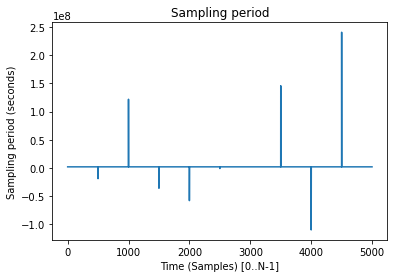

In [4]:
timestamp_channel = kymira_ecg_data["tstamp"]
plt.plot(numpy.diff(timestamp_channel))
plt.title("Sampling period")
plt.xlabel("Time (Samples) [0..N-1]")
plt.ylabel("Sampling period (seconds)")

## Individual ECG Channel Quality

### Summary statistics

In [5]:
kymira_ecg_data.describe()

,ecg1,ecg2,ecg3,ecg4,ecg5
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.000126,-0.000038,0.000136,0.000049,-0.000022
std,0.011058,0.009445,0.013553,0.012263,0.015235
min,-0.394520,-0.320560,-0.078830,-0.383420,-0.361810
25%,-0.001467,-0.000239,-0.002650,-0.000889,-0.001154
50%,0.000440,0.000022,-0.000165,-0.000166,-0.000279
75%,0.002409,0.000317,0.002410,0.000627,0.000565
max,0.291270,0.420020,0.624890,0.550320,0.658900


In [6]:
kymira_ecg_data = pre_process_ecg_trial(kymira_ecg_data)
kymira_ecg_data = denoise_ecg_trial(kymira_ecg_data)

### Time domain

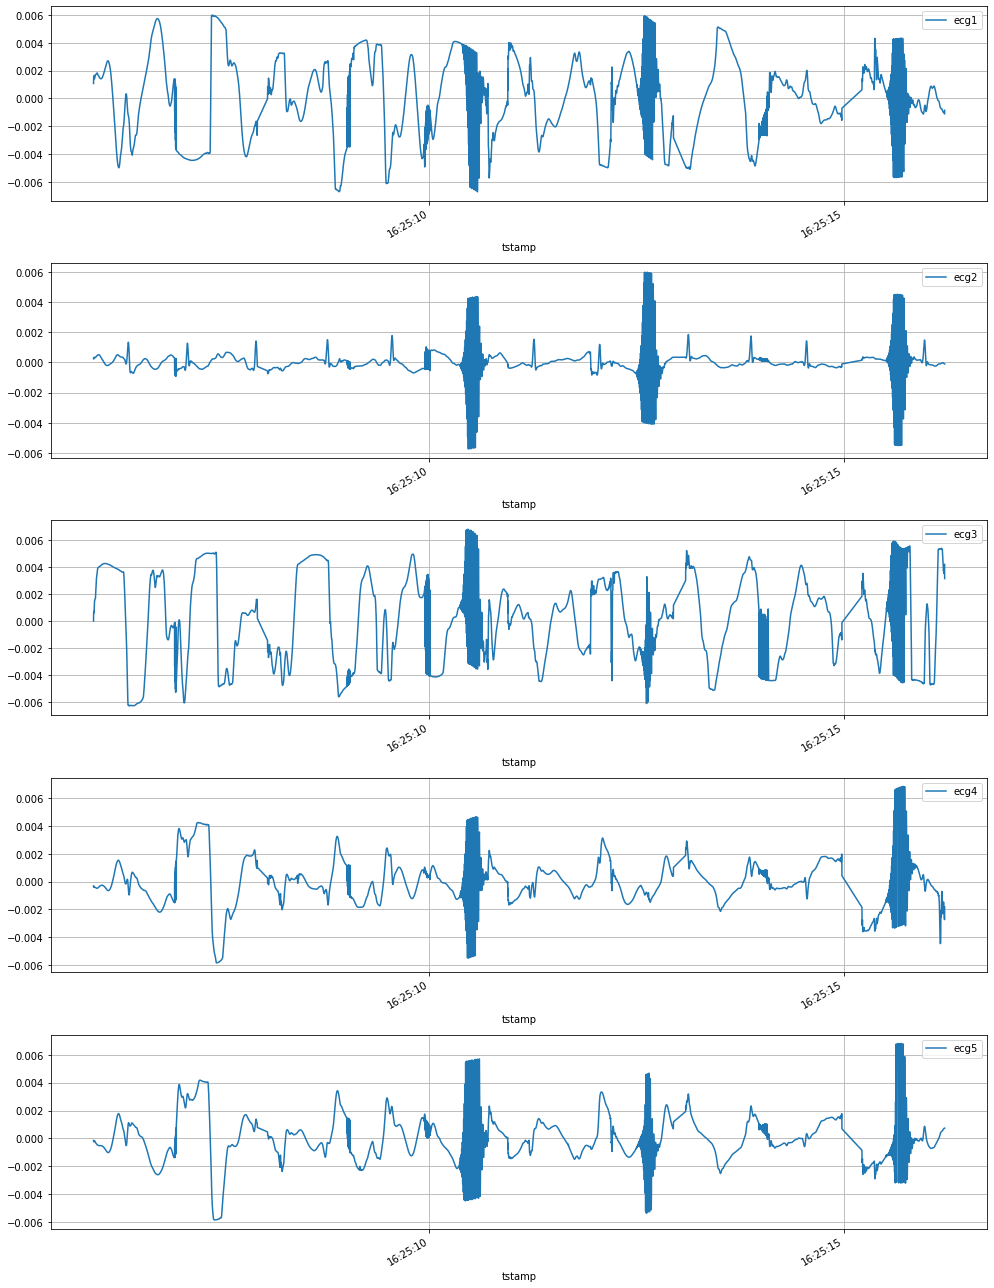

In [7]:
plt.figure(figsize=(14,18))
plt.subplot(511);plot_ecg_trial(kymira_ecg_data, channels=[1], ax=plt.gca());plt.grid(True)
plt.subplot(512);plot_ecg_trial(kymira_ecg_data, channels=[2], ax=plt.gca());plt.grid(True)
plt.subplot(513);plot_ecg_trial(kymira_ecg_data, channels=[3], ax=plt.gca());plt.grid(True)
plt.subplot(514);plot_ecg_trial(kymira_ecg_data, channels=[4], ax=plt.gca());plt.grid(True)
plt.subplot(515);plot_ecg_trial(kymira_ecg_data, channels=[5], ax=plt.gca());plt.grid(True)
plt.tight_layout()

### Frequency domain

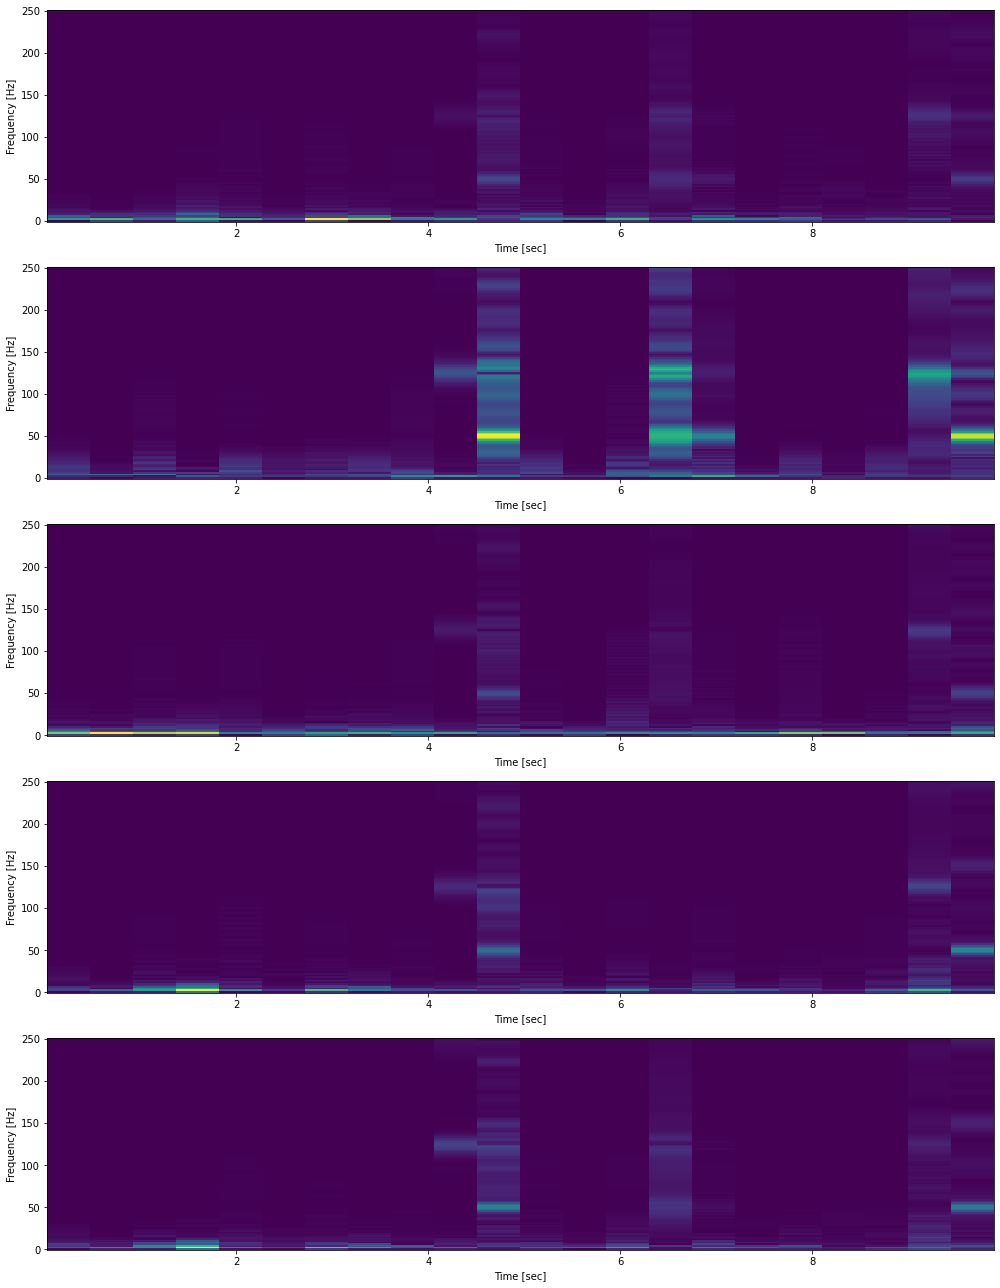

In [8]:
plt.figure(figsize=(14,18))
plt.subplot(511);plot_ecg_trial(kymira_ecg_data, channels=[1], ax=plt.gca(), plot_time_freq=True)
plt.subplot(512);plot_ecg_trial(kymira_ecg_data, channels=[2], ax=plt.gca(), plot_time_freq=True)
plt.subplot(513);plot_ecg_trial(kymira_ecg_data, channels=[3], ax=plt.gca(), plot_time_freq=True)
plt.subplot(514);plot_ecg_trial(kymira_ecg_data, channels=[4], ax=plt.gca(), plot_time_freq=True)
plt.subplot(515);plot_ecg_trial(kymira_ecg_data, channels=[5], ax=plt.gca(), plot_time_freq=True)
plt.tight_layout()